# Logistic

# dataroad

In [3]:
import pandas as pd

df = pd.read_csv('dataset/heart_preprocessed.csv')
print(df.shape,end= '\n\n')
df.head()
# PhysicalHealth는 회귀 계수 값 기반으로 제거
df.drop_duplicates(inplace=True)
X = df.drop(['HeartDisease','PhysicalHealth'], axis=1)
y = df['HeartDisease']
print(X.shape, y.shape)



(319795, 22)

(301304, 20) (301304,)


# basemodel

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from utils import evaluate_scores
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:

print("분리 후 데이터셋 shape")
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

x_train_scaled = x_train.copy()
x_test_scaled = x_test.copy()

scaler = StandardScaler()

num_cols = ['BMI','MentalHealth',"SleepTime"]

# 스케일링
scaler = StandardScaler()
x_train_scaled[num_cols] = scaler.fit_transform(x_train_scaled[num_cols])
x_test_scaled[num_cols] = scaler.transform(x_test_scaled[num_cols])


# -------------------------------
# 2️⃣ 모델 학습 및 예측
# -------------------------------
model = LogisticRegression(max_iter=3000, random_state=42)
model.fit(x_train_scaled, y_train)
#  예측 결과
y_test_pred = model.predict(x_test_scaled)


print("=== Evaluation train Metrics ===")
evaluate_scores(y_train, model.predict(x_train_scaled))
print("\n=== Evaluation test Metrics ===")
evaluate_scores(y_test, y_test_pred)



y_test_prob = model.predict_proba(x_test_scaled)[:, 1]

pr_auc = average_precision_score(y_test, y_test_prob)
print(f"PR-AUC: {pr_auc:.4f}")


# c 튜닝
+ class_weight 적용
+ 튜닝결과 기본 파리미터가 최적의 파라미터

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from utils import evaluate_scores


# -------------------------------
# 3) C 값만 튜닝할 로지스틱 회귀
# -------------------------------
base_model = LogisticRegression(
    max_iter=3000,
    class_weight='balanced'
)

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# train 데이터에서만 튜닝
grid.fit(x_train_scaled, y_train)

print("=== Best Params ===")
print(grid.best_params_)
print(f"Best CV F1: {grid.best_score_:.4f}")

# -------------------------------
# 4) 최적 모델
# -------------------------------
best_model = grid.best_estimator_

# 예측
y_train_pred = best_model.predict(x_train_scaled)
y_test_pred = best_model.predict(x_test_scaled)

# -------------------------------
# 5) 평가
# -------------------------------
print("\n=== Evaluation train Metrics ===")
evaluate_scores(y_train, y_train_pred)

print("\n=== Evaluation test Metrics ===")
evaluate_scores(y_test, y_test_pred)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
=== Best Params ===
{'C': 1}
Best CV F1: 0.3547

=== Evaluation train Metrics ===
Accuracy  : 0.7429
Precision : 0.2295
Recall    : 0.7811
F1 Score  : 0.3547
ROC AUC   : 0.7601

=== Evaluation test Metrics ===
Accuracy  : 0.7420
Precision : 0.2277
Recall    : 0.7745
F1 Score  : 0.3519
ROC AUC   : 0.7566


# 회귀계수 안정성 확보
+ No scaler
+ PhysicalHealth 제거

In [9]:
import statsmodels.api as sm

x_train_const = sm.add_constant(x_train)  # 타깃 제외

model = sm.Logit(y_train, x_train_const)
result = model.fit()

# -------------------------------
# 4) 결과 출력
# -------------------------------
print(result.summary())


# Race에서 계수가 안정적이지 않은 범주가 존재하지만, 제거하지않음. 설명가능력 때문에

Optimization terminated successfully.
         Current function value: 0.237438
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:           HeartDisease   No. Observations:               241043
Model:                          Logit   Df Residuals:                   241022
Method:                           MLE   Df Model:                           20
Date:                Sun, 22 Mar 2026   Pseudo R-squ.:                  0.2180
Time:                        19:34:52   Log-Likelihood:                -57233.
converged:                       True   LL-Null:                       -73184.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
const                                  -4.3521      0.068 

# 성능 전용 모델 학습

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)

# =========================================
# 0) 데이터 분리
# =========================================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
# 여기서는 threshold 선택 용으로 사용
X_train, X_calib, y_train, y_calib = train_test_split(
    X_train_full, y_train_full,
    test_size=0.25,   # train 60%, calib 20%, test 20%
    stratify=y_train_full,
    random_state=42
)

# =========================================
# 1) 스케일링 대상 변수
# =========================================
scale_cols = ['BMI', 'MentalHealth', 'SleepTime', 'AgeCategory', 'GenHealth']

preprocess = ColumnTransformer(
    transformers=[
        ('scale', StandardScaler(), scale_cols)
    ],
    remainder='passthrough'
)

# =========================================
# 2) 성능용 모델
# =========================================
perf_model = Pipeline([
    ('preprocess', preprocess),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        solver='liblinear',
        random_state=42
    ))
])

perf_model.fit(X_train, y_train)

# =========================================
# 3) calib set에서 threshold 선택
#    규칙:
#    - recall >= 0.70
#    - 그중 F1 최대
# =========================================
TARGET_RECALL = 0.70

calib_prob_raw = perf_model.predict_proba(X_calib)[:, 1]

thresholds = np.arange(0.01, 1.00, 0.01)
rows = []

for th in thresholds:
    pred = (calib_prob_raw >= th).astype(int)
    rows.append({
        "threshold": th,
        "accuracy": accuracy_score(y_calib, pred),
        "precision": precision_score(y_calib, pred, zero_division=0),
        "recall": recall_score(y_calib, pred, zero_division=0),
        "f1": f1_score(y_calib, pred, zero_division=0),
        "pred_pos_rate": pred.mean()
    })

th_df = pd.DataFrame(rows)

cand_df = th_df[th_df["recall"] >= TARGET_RECALL].copy()

if len(cand_df) > 0:
    best_row = cand_df.sort_values(
        ["f1", "precision", "threshold"],
        ascending=[False, False, False]
    ).iloc[0]
    rule_msg = f"recall >= {TARGET_RECALL:.2f} 조건에서 F1 최대"
else:
    best_recall = th_df["recall"].max()
    fallback_df = th_df[th_df["recall"] == best_recall].copy()
    best_row = fallback_df.sort_values(
        ["f1", "precision", "threshold"],
        ascending=[False, False, False]
    ).iloc[0]
    rule_msg = (
        f"recall >= {TARGET_RECALL:.2f} 만족 threshold 없음 -> "
        f"최대 recall({best_recall:.4f}) 후보 중 F1 최대"
    )

best_th = float(best_row["threshold"])

print("=== Threshold Selection on CALIB ===")
print("Rule:", rule_msg)
print(best_row)

print("\n=== Top threshold candidates on CALIB ===")
if len(cand_df) > 0:
    print(cand_df.sort_values(["f1", "precision"], ascending=False).head(10))
else:
    print(th_df.sort_values(["recall", "f1"], ascending=False).head(10))

# =========================================
# 4) TEST 평가
# =========================================
test_prob_raw = perf_model.predict_proba(X_test)[:, 1]
test_pred_perf = (test_prob_raw >= best_th).astype(int)

print("\n=== Performance model on TEST ===")
print(f"Threshold : {best_th:.2f}")
print(f"Accuracy  : {accuracy_score(y_test, test_pred_perf):.4f}")
print(f"Precision : {precision_score(y_test, test_pred_perf, zero_division=0):.4f}")
print(f"Recall    : {recall_score(y_test, test_pred_perf, zero_division=0):.4f}")
print(f"F1 Score  : {f1_score(y_test, test_pred_perf, zero_division=0):.4f}")
print(f"ROC AUC   : {roc_auc_score(y_test, test_prob_raw):.4f}")
print(f"PR AUC    : {average_precision_score(y_test, test_prob_raw):.4f}")

# =========================================
# 5) 예측 결과 저장
# =========================================
perf_result_df = pd.DataFrame({
    "y_true": y_test.values if hasattr(y_test, "values") else y_test,
    "perf_prob_raw": test_prob_raw,
    "perf_pred": test_pred_perf
})

print("\n=== Performance result sample ===")
print(perf_result_df.head(10))

=== Threshold Selection on CALIB ===
Rule: recall >= 0.70 조건에서 F1 최대
threshold        0.570000
accuracy         0.790246
precision        0.258175
recall           0.703778
f1               0.377769
pred_pos_rate    0.246627
Name: 56, dtype: float64

=== Top threshold candidates on CALIB ===
    threshold  accuracy  precision    recall        f1  pred_pos_rate
56       0.57  0.790246   0.258175  0.703778  0.377769       0.246627
55       0.56  0.783923   0.253854  0.715884  0.374802       0.255140
54       0.55  0.778829   0.250285  0.723955  0.371972       0.261695
53       0.54  0.772871   0.246569  0.734776  0.369234       0.269611
52       0.53  0.766665   0.242938  0.746148  0.366536       0.277875
51       0.52  0.758766   0.237958  0.756603  0.362049       0.287665
50       0.51  0.751083   0.233713  0.768525  0.358426       0.297506
49       0.50  0.743466   0.229672  0.779714  0.354827       0.307147
48       0.49  0.737044   0.226733  0.790902  0.352432       0.315594
47     

# Calibration 및 해석모델

=== Coefficient Table (sorted by abs_coef) ===
                                feature      coef  odds_ratio  abs_coef
3                                Stroke  1.184835    3.270146  1.184835
6                                   Sex  0.753842    2.125149  0.753842
13                        KidneyDisease  0.591601    1.806880  0.591601
16                           Race_Asian -0.568281    0.566499  0.568281
10                            GenHealth -0.512200    0.599176  0.512200
8                              Diabetic  0.453471    1.573765  0.453471
1                               Smoking  0.349428    1.418256  0.349428
12                               Asthma  0.293508    1.341124  0.293508
7                           AgeCategory  0.291792    1.338825  0.291792
5                           DiffWalking  0.247775    1.281172  0.247775
2                       AlcoholDrinking -0.240880    0.785936  0.240880
17                           Race_Black -0.218089    0.804054  0.218089
18               

c:\Python\Python310\lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


<Figure size 600x600 with 0 Axes>

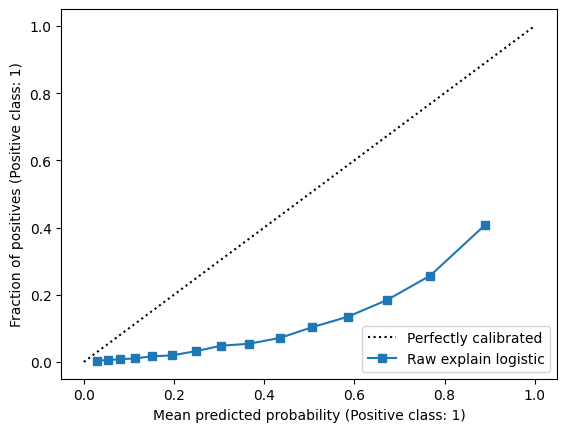

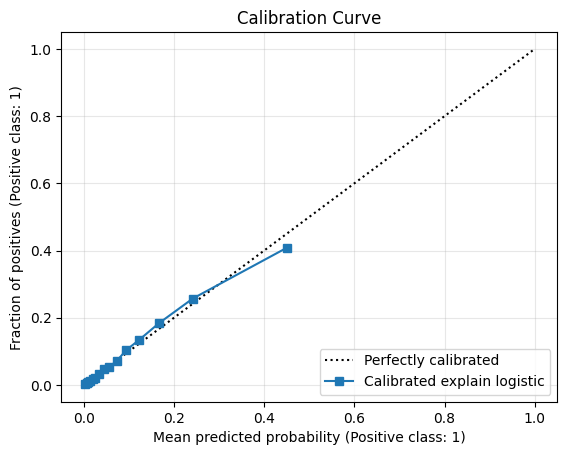


=== Probability result sample ===
   y_true  raw_prob  calibrated_prob
0       0  0.224744         0.030233
1       1  0.480743         0.085684
2       0  0.540844         0.105338
3       1  0.848712         0.340766
4       0  0.206619         0.027392
5       0  0.157263         0.020121
6       0  0.767361         0.238078
7       0  0.094629         0.011715
8       0  0.198259         0.026114
9       0  0.385240         0.060799


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss
)

# =========================================
# 0) 데이터 분리
# =========================================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train, X_calib, y_train, y_calib = train_test_split(
    X_train_full, y_train_full,
    test_size=0.25,   # train 60%, calib 20%, test 20%
    stratify=y_train_full,
    random_state=42
)

# =========================================
# 1) 설명용 base logistic (스케일링 X)
# =========================================
explain_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    solver="liblinear",
    random_state=42
)

explain_model.fit(X_train, y_train)

# =========================================
# 2) 계수 / Odds Ratio 확인
# =========================================
coef = explain_model.coef_[0]
odds_ratio = np.exp(coef)

coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coef": coef,
    "odds_ratio": odds_ratio,
    "abs_coef": np.abs(coef)
})

print("=== Coefficient Table (sorted by abs_coef) ===")
print(coef_df.sort_values("abs_coef", ascending=False))

print("\n=== Odds Ratio Table (descending) ===")
print(coef_df.sort_values("odds_ratio", ascending=False))

# =========================================
# 3) 캘리브레이션
# =========================================
cal_model = CalibratedClassifierCV(
    estimator=explain_model,
    method="sigmoid",
    cv="prefit"
)
cal_model.fit(X_calib, y_calib)

# =========================================
# 4) TEST 확률 평가
# =========================================
test_prob_raw = explain_model.predict_proba(X_test)[:, 1]
test_prob_cal = cal_model.predict_proba(X_test)[:, 1]

print("\n=== Explain/Probability model on TEST ===")
print(f"Raw ROC AUC        : {roc_auc_score(y_test, test_prob_raw):.4f}")
print(f"Raw PR AUC         : {average_precision_score(y_test, test_prob_raw):.4f}")
print(f"Calibrated ROC AUC : {roc_auc_score(y_test, test_prob_cal):.4f}")
print(f"Calibrated PR AUC  : {average_precision_score(y_test, test_prob_cal):.4f}")
print(f"Brier Score        : {brier_score_loss(y_test, test_prob_cal):.4f}")

# =========================================
# 5) Calibration curve 비교
# =========================================
plt.figure(figsize=(6, 6))

CalibrationDisplay.from_predictions(
    y_test,
    test_prob_raw,
    n_bins=15,
    strategy="quantile",
    name="Raw explain logistic"
)

CalibrationDisplay.from_predictions(
    y_test,
    test_prob_cal,
    n_bins=15,
    strategy="quantile",
    name="Calibrated explain logistic"
)

plt.title("Calibration Curve")
plt.grid(alpha=0.3)
plt.show()

# =========================================
# 6) 확률 결과 저장
# =========================================
prob_result_df = pd.DataFrame({
    "y_true": y_test.values if hasattr(y_test, "values") else y_test,
    "raw_prob": test_prob_raw,
    "calibrated_prob": test_prob_cal
})

print("\n=== Probability result sample ===")
print(prob_result_df.head(10))

# 모델 저장

In [12]:
import joblib

model_bundle = {
    "perf_model": perf_model,
    "threshold": best_th,
    "explain_model": explain_model,
    "cal_model": cal_model,
    "features": X.columns.tolist()
}

joblib.dump(model_bundle, "final_models.pkl")

print("모델 저장 완료")

모델 저장 완료


In [7]:
import joblib
d =joblib.load("final_models.pkl")
cal_model = d["cal_model"]

from utils import evaluate_scores
pred = cal_model.predict(x_test)
evaluate_scores(y_test, pred)

Accuracy  : 0.9111
Precision : 0.5407
Recall    : 0.1147
F1 Score  : 0.1892
ROC AUC   : 0.5525


In [8]:
import pandas as pd
pd.DataFrame(pred).value_counts()

0
0    59105
1     1156
Name: count, dtype: int64